In [1]:
import torch
import matplotlib.pyplot as plt
import torch.nn.functional as F
%matplotlib inline

In [3]:
words = open('names.txt', 'r').read().splitlines()

In [7]:
# Build the Vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)

In [64]:
# build the dataset
block_size = 3 # Context length: How many characters do we take to predict the next one?

def build_dataset(words):
    X, Y =[], []

    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix] # crop and append

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])  #80%
Xdev, Ydev = build_dataset(words[n1:n2]) # 10%
Xte, Yte = build_dataset(words[n2:]) #10%

torch.Size([182580, 3]) torch.Size([182580])
torch.Size([22767, 3]) torch.Size([22767])
torch.Size([22799, 3]) torch.Size([22799])


# We multiply randomly initalised weights of hidden Layer by a factor of 10, 100 to remove hockey stick loss, where the initial loss is too high compared to uniform distributed probability
# We multiply randomly initialised weights of input layer by a factor 10, 100 to remove the saturation concentration of 1, -1 where the gradients cannot learn as the gradient of tanh will always be 0 for -1, 1
# Now that we decided why to initialize weights properly, we need to figure what the initialised weights shouls be, we generally use kaiming init for linear = * 1/ fan_in ** 0.5, for tanh = * (5/3)/ fan_in ** 0.5, where fan_in the number of neurons in inout layer in our case (10 * 3) = 30
# Batch normalisation to make hidden layers gaussian to have 0 mean and unit std, at the same time we need the network to learn in the process rather than keep concentrating on making the hidden layers gaussian, so we introduce bngain for scaling and bnbias for shift
# we use batch norm layer to control the statistics of activations of neural net


In [65]:
# MLP revisited
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden alyer of the MLP

# We multiply randomly initalised weights of hidden Layer by a factor of 10, 100 to remove hockey stick loss, where the initial loss is too high compared to uniform distributed probability
# We multiply randomly initialised weights of input layer by a factor 10, 100 to remove the saturation concentration of 1, -1 where the gradients cannot learn as the gradient of tanh will always be 0 for -1, 1
# Now that we decided why to initialize weights properly, we need to figure what the initialised weights shouls be, we generally use kaiming init for linear = * 1/ fan_in ** 0.5, for tanh = * (5/3)/ fan_in ** 0.5, where fan_in the number of neurons in inout layer in our case (10 * 3) = 30
# Batch normalisation to make hidden layers gaussian to have 0 mean and unit std, at the same time we need the network to learn in the process rather than keep concentrating on making the hidden layers gaussian, so we introduce bngain for scaling and bnbias for shift
# we use batch norm layer to control the statistics of activations of neural net
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((vocab_size, n_embd),               generator =g)
W1 = torch.randn((n_embd * block_size, n_hidden),   generator=g) * (5/3)/((n_embd * block_size)**0.5) #* 0.2
#b1 = torch.randn(n_hidden,                          generator=g) * 0.01 Not used with batch norm, as it gets subracted when its subracted from mean, as we already have bnbias, we can comment this out
W2 = torch.randn((n_hidden, vocab_size),            generator=g) * 0.01
b2 = torch.randn(vocab_size,                        generator=g) * 0

bngain = torch.ones(1, n_hidden) # scaling for batch normalisation
bnbias = torch.zeros(1, n_hidden) # shift for batch normalisation
bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.ones((1, n_hidden))

parameters = [C, W1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) #number of parameters in total
for p in parameters:
    p.requires_grad = True


12097


In [70]:
# Optimization
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

    #minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # batch X, Y

    # forward pass
    emb = C[Xb] # embed the characters into vectors
    embcat = emb.view(emb.shape[0], -1) # Concatenate the vectors
    hpreact = embcat @ W1 #+ b1 # hidden layer pre-activation
    # BatchNorm Layer
    # ----------------------------
    bnmeani = hpreact.mean(0, keepdim = True)
    bnstdi = hpreact.std(0, keepdim = True)
    hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias # batch normalisation
    
    with torch.no_grad():
        bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
        bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi
    # -------------------------------------
    # Non-linearity
    h = torch.tanh(hpreact) # hidden layer
    logits = h @ W2 +b2 # output layer
    loss = F.cross_entropy(logits, Yb) # loss function

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    #update
    lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0: #print every once in a while
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())



      0/ 200000: 3.2885
  10000/ 200000: 2.2080
  20000/ 200000: 2.3458
  30000/ 200000: 1.9338
  40000/ 200000: 2.5117
  50000/ 200000: 1.8890
  60000/ 200000: 2.1108
  70000/ 200000: 2.3369
  80000/ 200000: 2.5553
  90000/ 200000: 2.1440
 100000/ 200000: 1.9966
 110000/ 200000: 2.0079
 120000/ 200000: 2.0462
 130000/ 200000: 2.1546
 140000/ 200000: 2.3030
 150000/ 200000: 1.9924
 160000/ 200000: 1.8889
 170000/ 200000: 2.2831
 180000/ 200000: 2.0151
 190000/ 200000: 2.1534


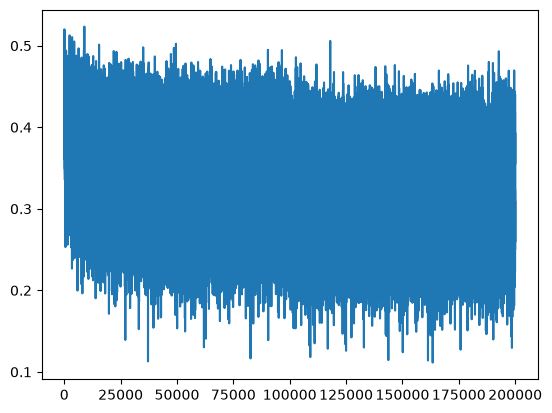

In [71]:
plt.plot(lossi)

In [74]:
@torch.no_grad() # this decoarator disables gradient tracking
def split_loss(split):
    x,y = {
        'train' : (Xtr, Ytr),
        'val' : (Xdev, Ydev),
        'test' : (Xte, Yte),
    }[split]
    emb = C[x] # (N, bloc_size, n_embd)
    embcat = emb.view(emb.shape[0], -1) # Concat into (N, bloc_size * n_embd)
    hpreact = embcat @ W1 #+ b1
    hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
    h = torch.tanh(hpreact) #(N, n_hidden)
    logits = h @ W2 + b2 # (n, vocab_size)
    loss = F. cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.066019296646118
val 2.1100497245788574


In [76]:
# Sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):

    out =[]
    context = [0] * block_size #initialize with all ...
    while True:
        # forward pass the neural net
        emb = C[torch.tensor([context])] # (1, block_size, n_embd)
        embcat = emb.view(1, -1) # Concat into (N, bloc_size * n_embd)
        hpreact = embcat @ W1 #+ b1
        hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
        h = torch.tanh(hpreact) #(N, n_hidden)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim =1)
        # sample from the ditribution
        ix = torch.multinomial(probs, num_samples = 1, generator = g).item()
        #shift the context window and track the samples
        context = context[1:] + [ix]
        out.append(ix)
        # if we sample the special '.' token, break
        if ix == 0:
            break

    print(''.join(itos[i] for i in out))

carmah.
ambrie.
khi.
milia.
aty.
salaysie.
mahnee.
delynn.
jareen.
ner.
kiah.
maiir.
kaleigh.
ham.
join.
quinton.
lilea.
jadiquinterri.
jaryni.
jaxen.
